# Time Series Pipeline — U.S. House Results
This notebook builds a time series of U.S. House election results interpolated 
onto the 2026 congressional district boundaries using population-weighted interpolation.

## How to use this notebook
1. Set your county parameters in the Configuration section below
2. Download the MEDSL election files (links in Issue #10) and VEST 2016/2018 shapefiles and place in data/raw/election_results/
3. Run all cells top to bottom
4. Outputs will be saved to data/processed/ with your county name in the filename

## Data sources
- Boundary files: data/raw/boundaries/ (TLC 2020, 2022, 2024 — already in repo)
- VEST boundary files: data/raw/election_results/ (tx_2016.zip, tx_2018.zip — download from VEST Harvard Dataverse https://doi.org/10.7910/DVN/NH5S2I and https://doi.org/10.7910/DVN/UBKYRU)
- Election results: MEDSL — see Issue #10 for download links
- Census blocks: data/raw/census/ (already in repo)

In [1]:
# =============================================================================
# CONFIGURATION — change these values for your county
# =============================================================================

COUNTY_FIPS = 427
COUNTY_NAME = 'STARR'

# Output prefix for saved files
COUNTY_SLUG = COUNTY_NAME.lower().replace(' ', '_')  # e.g. 'travis', 'harris', 'tarrant'

print(f"Running pipeline for: {COUNTY_NAME} County (FIPS: {COUNTY_FIPS})")

Running pipeline for: STARR County (FIPS: 427)


In [2]:
# =============================================================================
# IMPORTS
# =============================================================================

import geopandas as gpd
import pandas as pd
import numpy as np
import zipfile
import os

print("Libraries loaded")

Libraries loaded


In [3]:
# =============================================================================
# Import shared pipeline functions
# =============================================================================
import sys
sys.path.append('../scripts')
from pipeline_utils import (
    load_medsl,
    build_weights_table,
    patch_missing_precincts,
    interpolate_votes_to_districts,
)
import pipeline_viz as viz
print("Pipeline functions imported from scripts/pipeline_utils.py")
print("Plotting functions imported from scripts/pipeline_viz.py")

Pipeline functions imported from scripts/pipeline_utils.py
Plotting functions imported from scripts/pipeline_viz.py


## Step 1 — Load boundary files

We need five boundary files, one per election cycle:
- 2016 precinct boundaries: VEST 2016 shapefile (tx_2016.zip)
- 2018 precinct boundaries: VEST 2018 shapefile (tx_2018.zip)
- 2020 precinct boundaries: TLC 2020 shapefile
- 2022 precinct boundaries: TLC 2022 shapefile
- 2024 precinct boundaries: TLC 2024 shapefile

Using cycle-specific boundary files ensures population weights are calculated 
using the precinct shapes that were actually in use during each election.

All boundary files cover all Texas counties — we filter to our county using CNTY.

In [4]:
# =============================================================================
# STEP 1 — Load boundary files
# =============================================================================

# 2016 precinct boundaries — VEST shapefile
precincts_2016 = gpd.read_file('zip://../data/raw/election_results/tx_2016.zip!tx_2016.shp')
precincts_2016 = precincts_2016[precincts_2016['CNTY'] == COUNTY_FIPS].copy()
print(f"2016 precincts: {len(precincts_2016)}")

# 2018 precinct boundaries — VEST shapefile
precincts_2018 = gpd.read_file('zip://../data/raw/election_results/tx_2018.zip!tx_2018.shp')
precincts_2018 = precincts_2018[precincts_2018['CNTY'] == COUNTY_FIPS].copy()
print(f"2018 precincts: {len(precincts_2018)}")

# 2020 precinct boundaries — TLC shapefile
precincts_2020 = gpd.read_file('zip://../data/raw/boundaries/precincts20g_2020.zip!Precincts20G_2020.shp')
precincts_2020 = precincts_2020[precincts_2020['CNTY'] == COUNTY_FIPS].copy()
print(f"2020 precincts: {len(precincts_2020)}")

# 2022 precinct boundaries — TLC shapefile
precincts_2022 = gpd.read_file('zip://../data/raw/boundaries/precincts22g.zip!Precincts22G.shp')
precincts_2022 = precincts_2022[precincts_2022['CNTY'] == COUNTY_FIPS].copy()
print(f"2022 precincts: {len(precincts_2022)}")

# 2024 precinct boundaries — TLC shapefile
precincts_2024 = gpd.read_file('zip://../data/raw/boundaries/precincts24g.zip!Precincts24G.shp')
precincts_2024 = precincts_2024[precincts_2024['CNTY'] == COUNTY_FIPS].copy()
print(f"2024 precincts: {len(precincts_2024)}")

2016 precincts: 10
2018 precincts: 10
2020 precincts: 10
2022 precincts: 14
2024 precincts: 14


## Step 2 — Load 2026 congressional district boundaries

These are the target geography — the new district boundaries we want to 
translate historical results onto.

In [5]:
# =============================================================================
# STEP 2 — Load 2026 congressional district boundaries
# =============================================================================

districts = gpd.read_file('zip://../data/raw/boundaries/PLANC2333.zip!PLANC2333/PLANC2333.shp')
print(f"Total 2026 districts: {len(districts)}")
print(f"Columns: {list(districts.columns)}")

print(f"\nDistricts CRS: {districts.crs}")
print(f"Precincts CRS: {precincts_2020.crs}")

Total 2026 districts: 38
Columns: ['District', 'geometry']

Districts CRS: PROJCS["NAD_1983_Lambert_Conformal_Conic",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AUTHORITY["EPSG","4269"]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",31.1666666666667],PARAMETER["central_meridian",-100],PARAMETER["standard_parallel_1",27.4166666666667],PARAMETER["standard_parallel_2",34.9166666666667],PARAMETER["false_easting",1000000],PARAMETER["false_northing",1000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Precincts CRS: PROJCS["NAD_1983_Lambert_Conformal_Conic",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AUTHORITY["EPSG","4

## Step 3 — Load census block population data

Census blocks are the bridge between precinct boundaries and district boundaries.
Each block has an exact population count and sits entirely within one precinct 
and one district — allowing us to calculate population-weighted splits.

We use 2020 Census blocks for all election cycles (most recent available).

In [6]:
# =============================================================================
# STEP 3 — Load census block population data
# =============================================================================

blocks = gpd.read_file('zip://../data/raw/census/Blocks.zip!Blocks.shp')
blocks = blocks[blocks['CNTY'] == str(COUNTY_FIPS).zfill(3)].copy()
print(f"Census blocks: {len(blocks)}")

# Load population counts
pop = pd.read_csv('../data/raw/census/Blocks_Pop.txt', dtype={'SCTBKEY': str})
pop = pop[pop['SCTBKEY'].str.startswith('48' + str(COUNTY_FIPS).zfill(3))].copy()
print(f"Population records: {len(pop)}")

# Join population to blocks
blocks = blocks.merge(pop[['SCTBKEY', 'total']], on='SCTBKEY', how='left')
blocks['total'] = blocks['total'].fillna(0)
print(f"Total population: {blocks['total'].sum():,.0f}")

Census blocks: 2322
Population records: 2322
Total population: 65,920


## Step 4 — Build weights tables

We build one weights table per election cycle using the precinct boundaries 
that were in use during that election:

- 2016 weights: uses VEST 2016 precinct boundaries
- 2018 weights: uses VEST 2018 precinct boundaries
- 2020 weights: uses TLC 2020 precinct boundaries
- 2022 weights: uses TLC 2022 precinct boundaries
- 2024 weights: uses TLC 2024 precinct boundaries

Each weights table tells us what fraction of each precinct's population
falls inside each 2026 congressional district.

Note: Precinct boundaries changed between some cycles. Using cycle-specific 
boundary files ensures accuracy. For Travis County, VEST geometry analysis 
showed <0.2% population impact from boundary changes between 2016 and 2020.

In [7]:
# =============================================================================
# STEP 4 — Build weights tables
# =============================================================================

# Build weights tables — one per election cycle using cycle-specific boundaries
weights_2016 = build_weights_table(precincts_2016, districts, blocks, '2016')
weights_2018 = build_weights_table(precincts_2018, districts, blocks, '2018')
weights_2020 = build_weights_table(precincts_2020, districts, blocks, '2020')
weights_2022 = build_weights_table(precincts_2022, districts, blocks, '2022')
weights_2024 = build_weights_table(precincts_2024, districts, blocks, '2024')

2016 weights table: 13 rows
2016 weight validation — precincts not summing to 1.0: 0
2018 weights table: 13 rows
2018 weight validation — precincts not summing to 1.0: 0
2020 weights table: 13 rows
2020 weight validation — precincts not summing to 1.0: 0
2022 weights table: 17 rows
2022 weight validation — precincts not summing to 1.0: 0
2024 weights table: 17 rows
2024 weight validation — precincts not summing to 1.0: 0


## Step 5 — Save weights tables

In [8]:
# =============================================================================
# STEP 5 — Save weights tables
# =============================================================================
weights_2016.to_csv(f'../data/processed/{COUNTY_SLUG}_population_weights_2016.csv', index=False)
weights_2018.to_csv(f'../data/processed/{COUNTY_SLUG}_population_weights_2018.csv', index=False)
weights_2020.to_csv(f'../data/processed/{COUNTY_SLUG}_population_weights_2020.csv', index=False)
weights_2022.to_csv(f'../data/processed/{COUNTY_SLUG}_population_weights_2022.csv', index=False)
weights_2024.to_csv(f'../data/processed/{COUNTY_SLUG}_population_weights_2024.csv', index=False)
print(f"Saved {COUNTY_SLUG}_population_weights_2016.csv")
print(f"Saved {COUNTY_SLUG}_population_weights_2018.csv")
print(f"Saved {COUNTY_SLUG}_population_weights_2020.csv")
print(f"Saved {COUNTY_SLUG}_population_weights_2022.csv")
print(f"Saved {COUNTY_SLUG}_population_weights_2024.csv")

Saved starr_population_weights_2016.csv
Saved starr_population_weights_2018.csv
Saved starr_population_weights_2020.csv
Saved starr_population_weights_2022.csv
Saved starr_population_weights_2024.csv


## Step 6 — Load election results

We load U.S. House precinct-level results from MEDSL for each election cycle.
Each file covers all Texas counties — we filter to our county using county_name.

Note on 2016: the file uses different column names (state_postal, party) 
compared to later years (state_po, party_simplified). County names are also 
in title case (e.g. "Travis County") rather than uppercase ("TRAVIS").

Note on 2022/2024: MEDSL files may contain split precinct IDs with letter 
suffixes (e.g. 4530150A, 4530150B). These are precincts that straddle district 
boundaries. We strip the suffix before matching to boundary files.

Note on 2024: Some counties use a different precinct ID prefix in MEDSL 2024 
files. For Travis County, MEDSL uses 227xxxx instead of 453xxxx — we correct 
this before matching.

In [9]:
# =============================================================================
# STEP 6 — Load election results
# =============================================================================
results_2016 = load_medsl('../data/raw/election_results/HOUSE_precinct_general_2016.tab', ',', COUNTY_NAME.title() + ' County', 2016, COUNTY_FIPS)
results_2018 = load_medsl('../data/raw/election_results/HOUSE_precinct_general_2018.csv', ',', COUNTY_NAME, 2018, COUNTY_FIPS)
results_2020 = load_medsl('../data/raw/election_results/HOUSE_precinct_general_2020.csv', ',', COUNTY_NAME, 2020, COUNTY_FIPS)
results_2022 = load_medsl('../data/raw/election_results/HOUSE_precinct_general_2022.csv', ',', COUNTY_NAME, 2022, COUNTY_FIPS)
results_2024 = load_medsl('../data/raw/election_results/HOUSE_precinct_general_2024.csv', ',', COUNTY_NAME, 2024, COUNTY_FIPS)

2016: 30 rows, 10 unique precincts
2018: 20 rows, 10 unique precincts
2020: 30 rows, 10 unique precincts
2022: 28 rows, 14 unique precincts
2024: 28 rows, 14 unique precincts


## Note — 2018 boundary patch for Galveston County

The VEST 2018 Texas shapefile is missing 8 Bexar County precincts that exist in 
MEDSL 2018 election results (291147-291151, 293209-293210, 294213). This is the 
same type of gap we found in Collin County — a genuine coverage limitation in 
VEST's source data, not something specific to our pipeline.

We patch this by using the 2020 TLC boundary shapes for the 8 missing precincts, 
since they exist with stable identifiers in that file. This is a reasonable 
approximation but introduces minor uncertainty for those specific precincts in 2018 — 
their actual 2018 boundaries may have differed slightly from their 2020 boundaries.

Affected precincts: 291147–291151, 293209–293210, 294213 (8 of 734 total)

In [10]:
# =============================================================================
# Patch 2018 weights table — VEST 2018 boundary file is missing precincts
# that exist in MEDSL 2018 results (Galveston has no gap, so this is a no-op).
# See pipeline_utils.patch_missing_precincts for full explanation.
# =============================================================================
weights_2018 = patch_missing_precincts(results_2018, weights_2018, precincts_2020, districts, blocks, '2018')

Missing 2018 precincts: []


## Step 7 — Run interpolation

For each election cycle we apply the appropriate weights table to the 
election results to produce interpolated vote totals by 2026 district.

- 2016: uses 2016 weights table (VEST 2016 boundaries)
- 2018: uses 2018 weights table (VEST 2018 boundaries)
- 2020: uses 2020 weights table (TLC 2020 boundaries)
- 2022: uses 2022 weights table (TLC 2022 boundaries)
- 2024: uses 2024 weights table (TLC 2024 boundaries)

In [11]:
# =============================================================================
# STEP 7 — Run interpolation
# =============================================================================
interp_2016 = interpolate_votes_to_districts(results_2016, weights_2016, 2016)
interp_2018 = interpolate_votes_to_districts(results_2018, weights_2018, 2018)
interp_2020 = interpolate_votes_to_districts(results_2020, weights_2020, 2020)
interp_2022 = interpolate_votes_to_districts(results_2022, weights_2022, 2022)
interp_2024 = interpolate_votes_to_districts(results_2024, weights_2024, 2024)

2016: original=10,333, interpolated=10,333, diff=0.00
2018: original=9,542, interpolated=9,542, diff=0.00
2020: original=15,949, interpolated=15,949, diff=0.00
2022: original=10,205, interpolated=10,205, diff=0.00
2024: original=14,640, interpolated=14,640, diff=0.00


## Step 8 — Combine into time series and save

In [12]:
# =============================================================================
# STEP 8 — Combine into time series and save
# =============================================================================

time_series = pd.concat([
    interp_2016, interp_2018, interp_2020, interp_2022, interp_2024
], ignore_index=True)

time_series = time_series[['year', 'new_district_id', 'candidate', 'party', 'estimated_votes']]
time_series['party'] = time_series['party'].str.upper()
party_map = {'DEMOCRATIC': 'DEMOCRAT', 'GREEN': 'OTHER'}
time_series['party'] = time_series['party'].replace(party_map)

output_path = f'../data/processed/{COUNTY_SLUG}_house_time_series.csv'
time_series.to_csv(output_path, index=False)

print(f"Saved: {output_path}")
print(f"\nFinal time series: {len(time_series)} rows")
print(time_series.groupby(['year', 'party'])['estimated_votes'].sum().unstack().round(0))

Saved: ../data/processed/starr_house_time_series.csv

Final time series: 24 rows
party  DEMOCRAT  LIBERTARIAN  OTHER  REPUBLICAN
year                                           
2016     8866.0          NaN  141.0      1326.0
2018     9121.0        421.0    NaN         NaN
2020    11804.0        233.0    NaN      3912.0
2022     7196.0          NaN    NaN      3009.0
2024    10108.0          NaN    NaN      4532.0


In [13]:
# Preview the time series
print(time_series.head(20).to_string())
print(f"\nSample — District 37 across all years:")
print(time_series[time_series['new_district_id'] == 37][['year', 'candidate', 'party', 'estimated_votes']].to_string())

    year  new_district_id candidate        party  estimated_votes
0   2016               15      Cary        OTHER         0.243316
1   2016               15   Cuellar     DEMOCRAT         9.072193
2   2016               15    Hardin   REPUBLICAN         3.580214
3   2016               28      Cary        OTHER       140.756684
4   2016               28   Cuellar     DEMOCRAT      8856.927807
5   2016               28    Hardin   REPUBLICAN      1322.419786
6   2018               15   CUELLAR     DEMOCRAT         6.743316
7   2018               15    THOMAS  LIBERTARIAN         0.764706
8   2018               28   CUELLAR     DEMOCRAT      9114.256684
9   2018               28    THOMAS  LIBERTARIAN       420.235294
10  2020               15   CONGDON  LIBERTARIAN         0.000000
11  2020               15   CUELLAR     DEMOCRAT         7.994652
12  2020               15   WHITTEN   REPUBLICAN         4.379679
13  2020               28   CONGDON  LIBERTARIAN       233.000000
14  2020  

## Step 9 — Visualizations

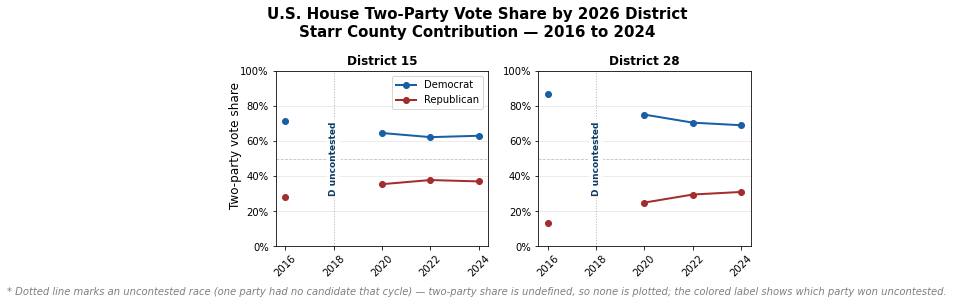

In [14]:
# =============================================================================
# STEP 9 — Visualizations
# =============================================================================
pivot = viz.build_two_party_pivot(time_series)
pivot_2026 = pivot  # alias reused by the Step 10 map cells below

_ = viz.plot_trend_lines(pivot, COUNTY_NAME, COUNTY_SLUG)

## Step 10 — Maps

Choropleth maps showing U.S. House two-party vote share by 2026 congressional 
district within Travis County — 2016 to 2024.

Data represents Travis County voter contributions only, not full district results.

In [15]:
# =============================================================================
# STEP 10 — Maps
# =============================================================================

# Load 2026 districts and clip to county boundary
county_boundary = precincts_2020.dissolve()  # Dissolve all precincts into one county boundary shape
districts_clipped = gpd.clip(districts.to_crs(precincts_2020.crs), county_boundary)
print(f"Clipped districts: {len(districts_clipped)}")
print(f"Districts: {sorted(districts_clipped['District'].unique())}")

Clipped districts: 2
Districts: [15, 28]


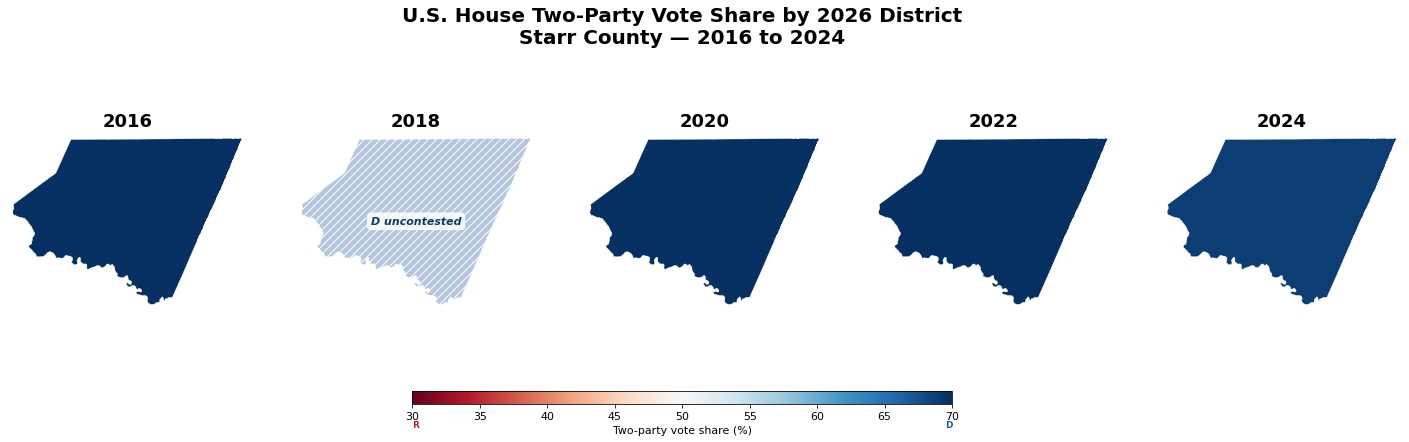

In [16]:
_ = viz.plot_vote_share_map(pivot_2026, districts_clipped, COUNTY_NAME, COUNTY_SLUG)

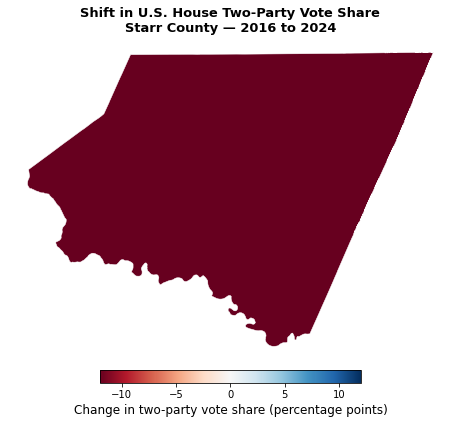

In [17]:
_ = viz.plot_change_map(pivot_2026, districts_clipped, COUNTY_NAME, COUNTY_SLUG)

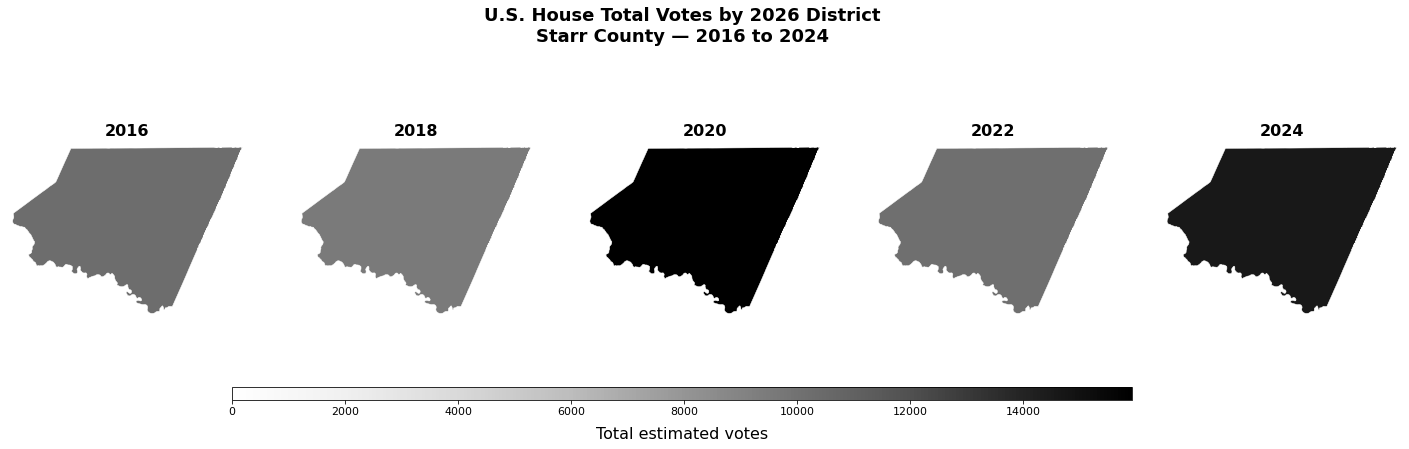

In [18]:
_ = viz.plot_turnout_map(time_series, districts_clipped, COUNTY_NAME, COUNTY_SLUG)